# Support Vector Machine (SVM) for Binary Classification
## Objective
To implement SVM for binary classification and analyze its performance using preprocessing and model evaluation.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

 # Dataset used is breast cancer dataset #

In [5]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.head())
print(y.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

# Data exploration #

In [6]:
print(X.shape)

(569, 30)


In [7]:
print(X.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [8]:
print(y.value_counts())

1    357
0    212
Name: count, dtype: int64


In [9]:
print(X.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

## Data preprocessing:Feature Scaling using StandardScaler

StandardScaler is used to standardize the feature values so that all features are on the same scale.  
This is important for SVM because it is a distance-based algorithm and works based on margins and hyperplanes.

- `fit_transform()` is applied on the training data to calculate the mean and standard deviation and then transform the data.
- `transform()` is applied on the testing data using the same scaling parameters learned from the training data.

This helps in avoiding data leakage and ensures fair model evaluation.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Working of Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm mainly used for binary classification problems.  
Its main objective is to classify the data into two different classes by finding the best possible decision boundary.

## 1. Hyperplane
SVM works by creating a decision boundary called a **hyperplane** that separates the data points of two classes.
- In a two-dimensional dataset, the hyperplane is a straight line.
- In higher dimensions, it is referred to as a hyperplane.

The equation of the hyperplane is:

w · x + b = 0

Where:
- **w** = weight vector
- **x** = input feature vector
- **b** = bias term

## 2. Maximum Margin
SVM does not choose just any decision boundary.  
It selects the hyperplane that has the **maximum margin**.

Margin is the distance between the hyperplane and the nearest data points from both classes.

A larger margin improves the model’s accuracy and generalization performance.

## 3. Support Vectors
The data points that are closest to the hyperplane are called **support vectors**.

These points are the most important because they determine the position of the hyperplane.

If the support vectors change, the decision boundary also changes.

## 4. Classification
After training, the SVM model checks on which side of the hyperplane a new data point lies.

- If it lies on one side, it is classified as **Class 0**
- If it lies on the other side, it is classified as **Class 1**

Thus, SVM performs binary classification by separating the classes with an optimal hyperplane having maximum margin.

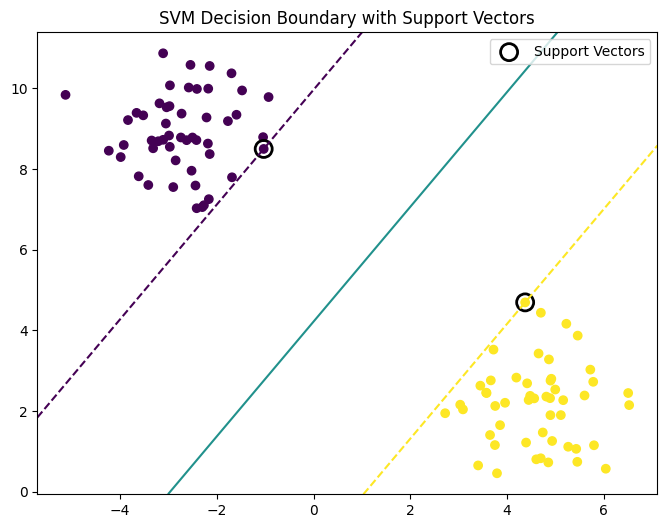

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Create sample binary dataset
X_vis, y_vis = make_blobs(n_samples=100, centers=2, random_state=42)

# Train SVM
svm_vis = SVC(kernel='linear')
svm_vis.fit(X_vis, y_vis)

# Plot data points
plt.figure(figsize=(8, 6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis)

# Mark support vectors
plt.scatter(
    svm_vis.support_vectors_[:, 0],
    svm_vis.support_vectors_[:, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

# Decision boundary and margins
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_vis.decision_function(xy).reshape(XX.shape)

plt.contour(
    XX, YY, Z,
    levels=[-1, 0, 1],
    linestyles=['--', '-', '--']
)

plt.title("SVM Decision Boundary with Support Vectors")
plt.legend()
plt.show()

In [12]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [13]:
y_pred = svm_model.predict(X_test)

## Performance Evaluation Metrics

The trained SVM model is evaluated using multiple performance metrics:

- **Accuracy:** Represents the ratio of correctly predicted observations to the total observations.
- **Classification Report:** Includes precision, recall, F1-score, and support values for detailed class-wise analysis.
- **Confusion Matrix:** Shows true positives, true negatives, false positives, and false negatives.

These metrics provide a comprehensive understanding of the model’s classification performance.

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.956140350877193
[[41  2]
 [ 3 68]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



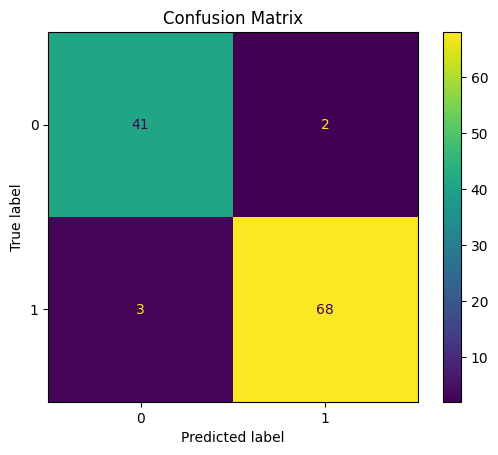

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()